# 1. Average Performance of I-V figures of 4 types of LEDs and the resistor
Error bar anaylysis is also included

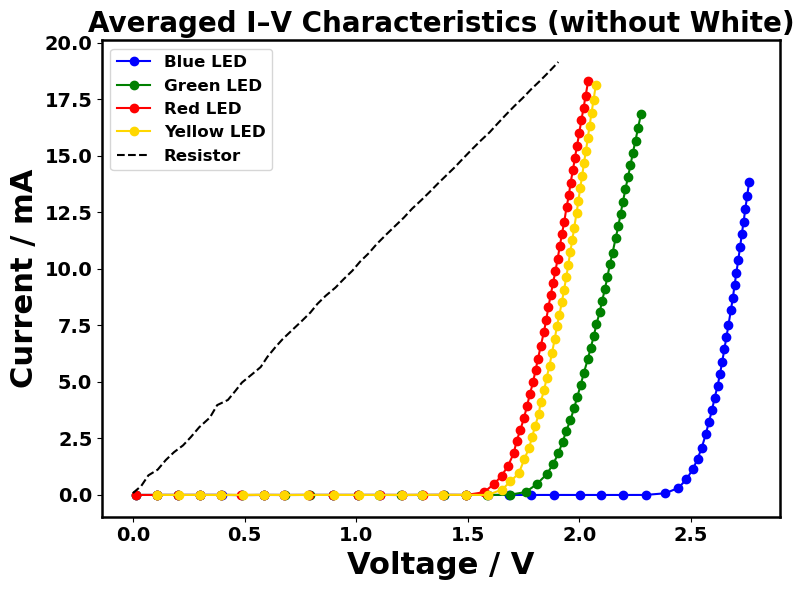

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def average_iv(file_list):
    Vs = []
    Is = []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V)
        Is.append(I)

    # target length = shortest run
    n = min(len(v) for v in Vs)

    Vs_trim = []
    Is_trim = []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V = V[drop:]
            I = I[drop:]
        else:
            V = V[:n]
            I = I[:n]
        Vs_trim.append(V)
        Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# ----------------- Existing base -----------------
base = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260121/raw data_finalised'

# Load data
V_blue_avg, I_blue_avg = average_iv([
    f'{base}/blue/blue_IV_run1.csv',
    f'{base}/blue/blue_IV_run2.csv',
    f'{base}/blue/blue_IV_run3.csv',
    f'{base}/blue/blue_IV_run4.csv',
    f'{base}/blue/blue_IV_run5.csv',
])

V_green_avg, I_green_avg = average_iv([
    f'{base}/green/green_IV_run1.csv',
    f'{base}/green/green_IV_run2.csv',
    f'{base}/green/green_IV_run3.csv',
    f'{base}/green/green_IV_run4.csv',
    f'{base}/green/green_IV_run5.csv',
])

V_red_avg, I_red_avg = average_iv([
    f'{base}/red/red_IV_run1.csv',
    f'{base}/red/red_IV_run2.csv',
    f'{base}/red/red_IV_run3.csv',
    f'{base}/red/red_IV_run4.csv',
    f'{base}/red/red_IV_run5.csv',
])

V_yellow_avg, I_yellow_avg = average_iv([
    f'{base}/yellow/yellow_IV_run1.csv',
    f'{base}/yellow/yellow_IV_run2.csv',
    f'{base}/yellow/yellow_IV_run3.csv',
    f'{base}/yellow/yellow_IV_run4.csv',
    f'{base}/yellow/yellow_IV_run5.csv',
])

V_res_avg, I_res_avg = average_iv([
    f'{base}/resistor/resistor_IV_run1.csv',
    f'{base}/resistor/resistor_IV_run2.csv',
    f'{base}/resistor/resistor_IV_run3.csv',
    f'{base}/resistor/resistor_IV_run4.csv',
    f'{base}/resistor/resistor_IV_run5.csv',
])


# ----------------- Plot -----------------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_blue_avg, I_blue_avg, 'o-', label='Blue LED', color='blue')
plt.plot(V_green_avg, I_green_avg, 'o-', label='Green LED', color='green')
plt.plot(V_red_avg, I_red_avg, 'o-', label='Red LED', color='red')
plt.plot(V_yellow_avg, I_yellow_avg, 'o-', label='Yellow LED', color='gold')
plt.plot(V_res_avg, I_res_avg, 'k--', label='Resistor')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Averaged I–V Characteristics (without White)', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left')
plt.tight_layout()
plt.savefig("Averaged I–V Characteristics (without White).png", dpi=600)
plt.show()

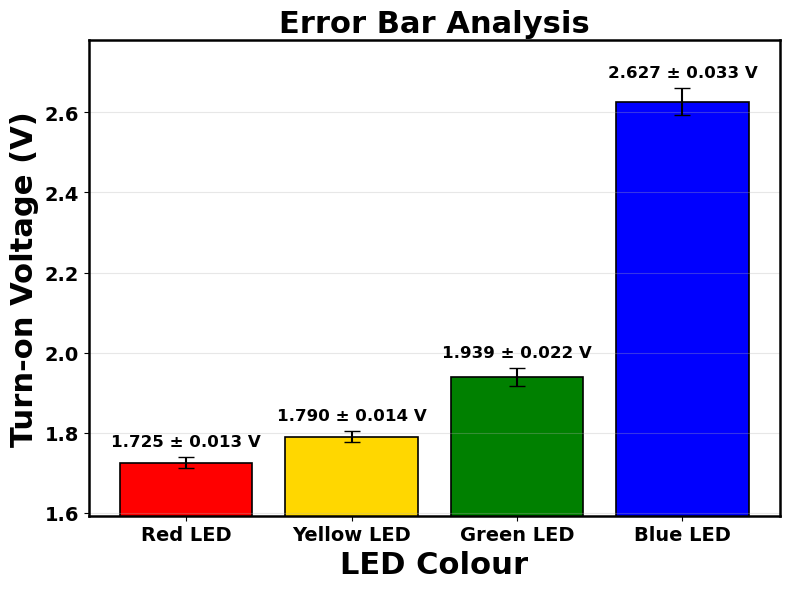

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Load turn-on voltages
# =========================
data_dir = r"/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260121/raw data_finalised"
csv_name = "Turn-on Voltages.csv"
csv_path = os.path.join(data_dir, csv_name)

df = pd.read_csv(csv_path)

labels = ["Red LED", "Yellow LED", "Green LED", "Blue LED"]
col_map = {
    "Red LED": "Red",
    "Yellow LED": "Yellow",
    "Green LED": "Green",
    "Blue LED": "Blue",
    # "White LED": "White",
}

# Extract datasets (drop NaNs just in case)
datasets = [df[col_map[lbl]].dropna().to_numpy(dtype=float) for lbl in labels]

# =========================
# 2) Stats (mean ± sample SD)
# =========================
means = [np.mean(arr) for arr in datasets]
errors = [np.std(arr, ddof=1) for arr in datasets]  # ddof=1 = sample SD

x = np.arange(len(labels))

# =========================
# 3) Plot mean ± SD
# =========================
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

# Color mapping for bars (optional)
bar_colors = {
    "Red LED": "red",
    "Yellow LED": "gold",
    "Green LED": "green",
    "Blue LED": "blue",
    # "White LED": "gray",
}
colors = [bar_colors[lbl] for lbl in labels]

bars = plt.bar(
    x, means, yerr=errors, capsize=6,
    color=colors,
    edgecolor='k', linewidth=1.2
)

plt.xticks(x, labels, fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.xlabel("LED Colour", fontsize=22, fontweight='bold')
plt.ylabel("Turn-on Voltage (V)", fontsize=22, fontweight='bold')
plt.title("Error Bar Analysis", fontsize=22, fontweight='bold')

ymax = max(m + s for m, s in zip(means, errors)) + 0.12
ymin = min(m - s for m, s in zip(means, errors)) - 0.12
plt.ylim(max(0, ymin), ymax)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for bar, m, s in zip(bars, means, errors):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + s + 0.02,
        f"{m:.3f} ± {s:.3f} V",
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

out_path = os.path.join(data_dir, "Turn-on Voltage Mean and SD.png")
plt.savefig(out_path, dpi=600)

plt.show()

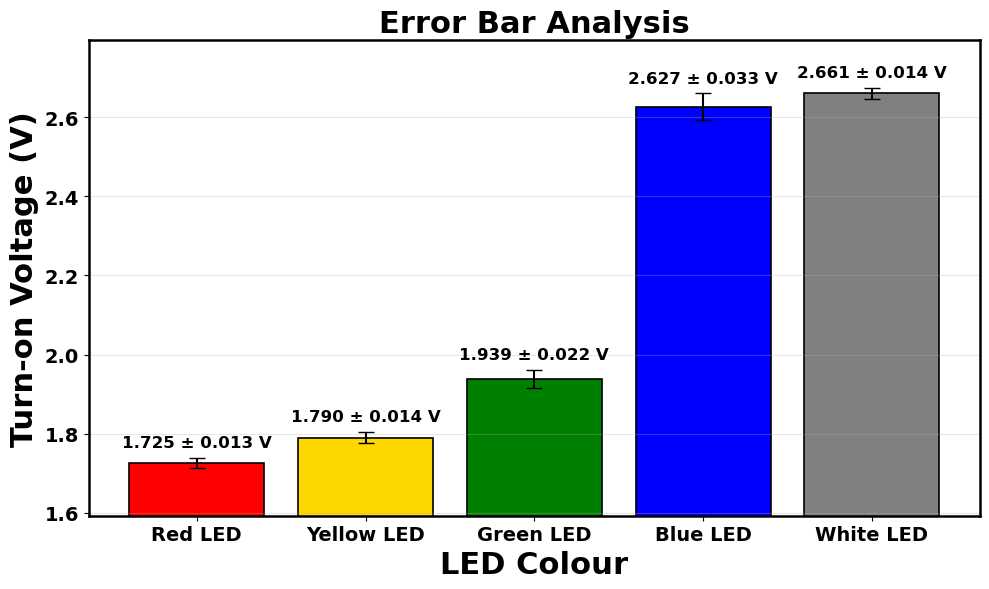

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Load turn-on voltages
# =========================
data_dir = r"/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260121/raw data_finalised"
csv_name = "Turn-on Voltages.csv"
csv_path = os.path.join(data_dir, csv_name)

df = pd.read_csv(csv_path)

labels = ["Red LED", "Yellow LED", "Green LED", "Blue LED", "White LED"]
col_map = {
    "Red LED": "Red",
    "Yellow LED": "Yellow",
    "Green LED": "Green",
    "Blue LED": "Blue",
    "White LED": "White",
}

datasets = [df[col_map[lbl]].dropna().to_numpy(dtype=float) for lbl in labels]

# =========================
# 2) Stats (mean ± sample SD)
# =========================
means = [np.mean(arr) for arr in datasets]
errors = [np.std(arr, ddof=1) for arr in datasets]  # ddof=1 = sample SD

x = np.arange(len(labels))

# =========================
# 3) Plot mean ± SD
# =========================
plt.figure(figsize=(10, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

# Color mapping for bars (optional)
bar_colors = {
    "Red LED": "red",
    "Yellow LED": "gold",
    "Green LED": "green",
    "Blue LED": "blue",
    "White LED": "gray",
}
colors = [bar_colors[lbl] for lbl in labels]

bars = plt.bar(
    x, means, yerr=errors, capsize=6,
    color=colors,
    edgecolor='k', linewidth=1.2
)

plt.xticks(x, labels, fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.xlabel("LED Colour", fontsize=22, fontweight='bold')
plt.ylabel("Turn-on Voltage (V)", fontsize=22, fontweight='bold')
plt.title("Error Bar Analysis", fontsize=22, fontweight='bold')

ymax = max(m + s for m, s in zip(means, errors)) + 0.12
ymin = min(m - s for m, s in zip(means, errors)) - 0.12
plt.ylim(max(0, ymin), ymax)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for bar, m, s in zip(bars, means, errors):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + s + 0.02,
        f"{m:.3f} ± {s:.3f} V",
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

out_path = os.path.join(data_dir, "Turn-on Voltage Mean and SD (with White).png")
plt.savefig(out_path, dpi=600)

plt.show()

# 2. Extension - Liquid N2 cooled LED

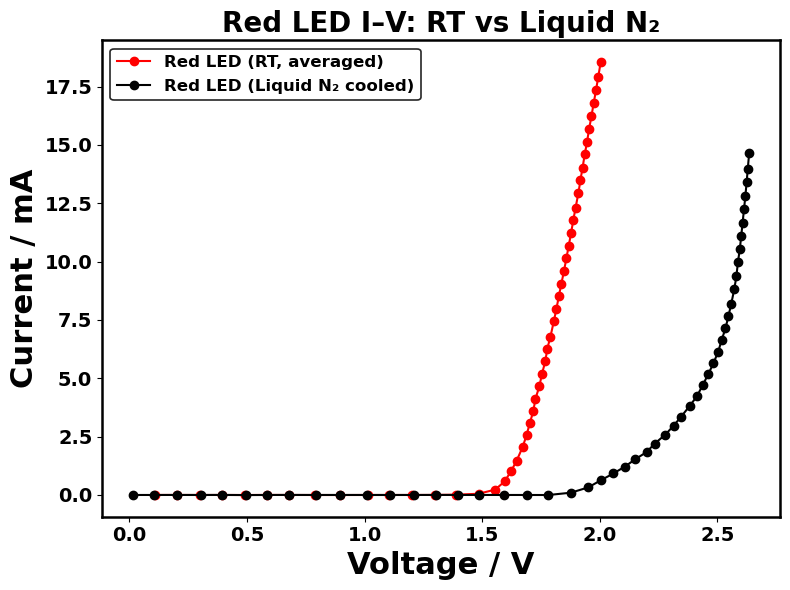

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data/red'

V_red_rt, I_red_rt = average_iv([
    f'{base_rt}/red_IV.csv',
    f'{base_rt}/red_IV_2.csv',
    f'{base_rt}/red_IV_3.csv',
    f'{base_rt}/red_IV_4.csv',
    f'{base_rt}/red_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_red_ln2, I_red_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/red_LiquidN2_cooled.csv'
)

# --------- Plot ----------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_red_rt, I_red_rt, 'o-', label='Red LED (RT, averaged)', color='red')
plt.plot(V_red_ln2, I_red_ln2, 'o-', label='Red LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Red LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()
plt.savefig("Red_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

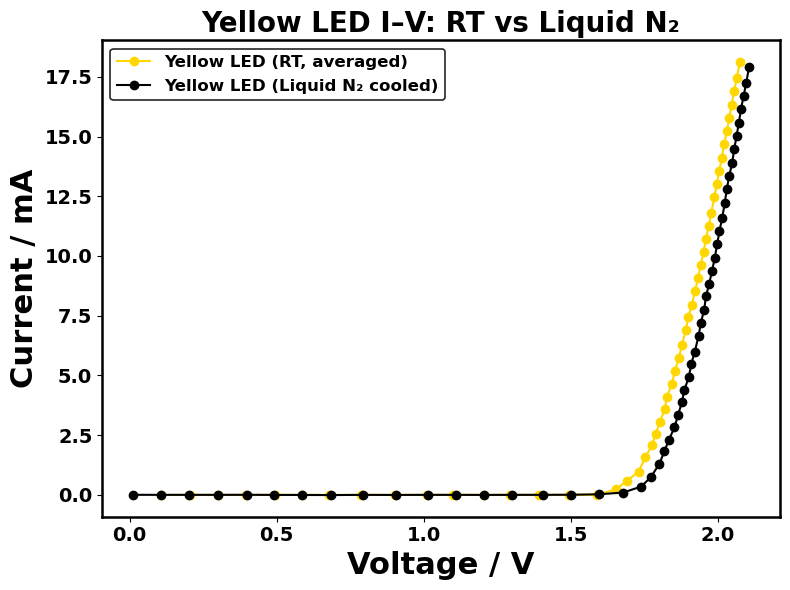

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data/yellow'

V_yellow_rt, I_yellow_rt = average_iv([
    f'{base_rt}/yellow_IV.csv',
    f'{base_rt}/yellow_IV_2.csv',
    f'{base_rt}/yellow_IV_3.csv',
    f'{base_rt}/yellow_IV_4.csv',
    f'{base_rt}/yellow_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_yellow_ln2, I_yellow_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/yellow_LiquidN2_cooled.csv'
)

# --------- Plot ----------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_yellow_rt, I_yellow_rt, 'o-', label='Yellow LED (RT, averaged)', color='gold')
plt.plot(V_yellow_ln2, I_yellow_ln2, 'o-', label='Yellow LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Yellow LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()
plt.savefig("Yellow_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

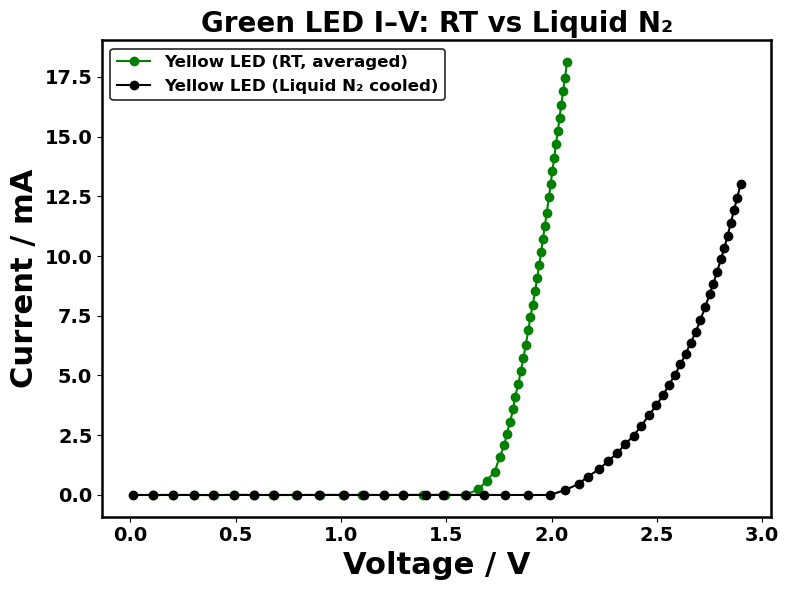

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/raw data/green'

V_green_rt, I_green_rt = average_iv([
    f'{base_rt}/green_IV.csv',
    f'{base_rt}/green_IV_2.csv',
    f'{base_rt}/green_IV_3.csv',
    f'{base_rt}/green_IV_4.csv',
    f'{base_rt}/green_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_yellow_ln2, I_yellow_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/green_LiquidN2_cooled.csv'
)

# --------- Plot ----------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_yellow_rt, I_yellow_rt, 'o-', label='Yellow LED (RT, averaged)', color='green')
plt.plot(V_yellow_ln2, I_yellow_ln2, 'o-', label='Yellow LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Green LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()
plt.savefig("Green_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

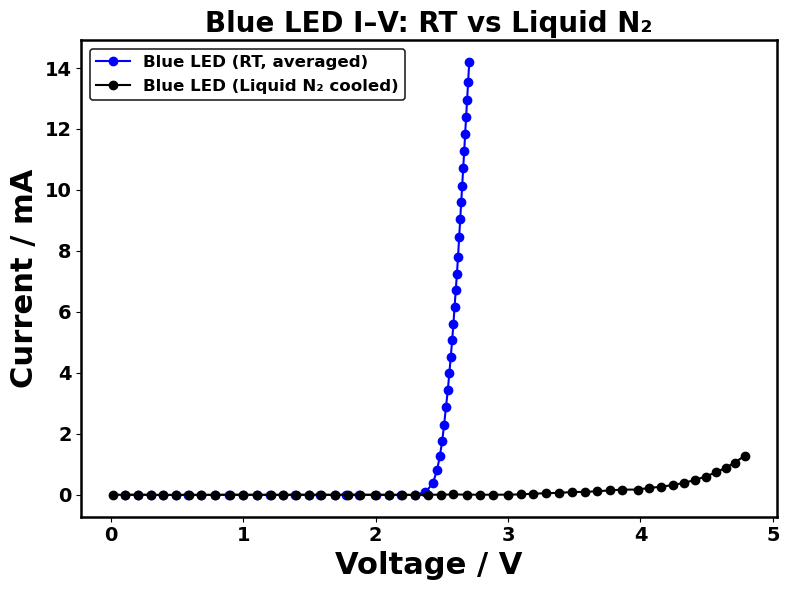

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/raw data/blue'

V_blue_rt, I_blue_rt = average_iv([
    f'{base_rt}/blue_IV.csv',
    f'{base_rt}/blue_IV_2.csv',
    f'{base_rt}/blue_IV_3.csv',
    f'{base_rt}/blue_IV_4.csv',
    f'{base_rt}/blue_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_blue_ln2, I_blue_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/blue_LiquidN2_cooled.csv'
)

# --------- Plot ----------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_blue_rt, I_blue_rt, 'o-', label='Blue LED (RT, averaged)', color='blue')
plt.plot(V_blue_ln2, I_blue_ln2, 'o-', label='Blue LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Blue LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()
#plt.savefig("Blue_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

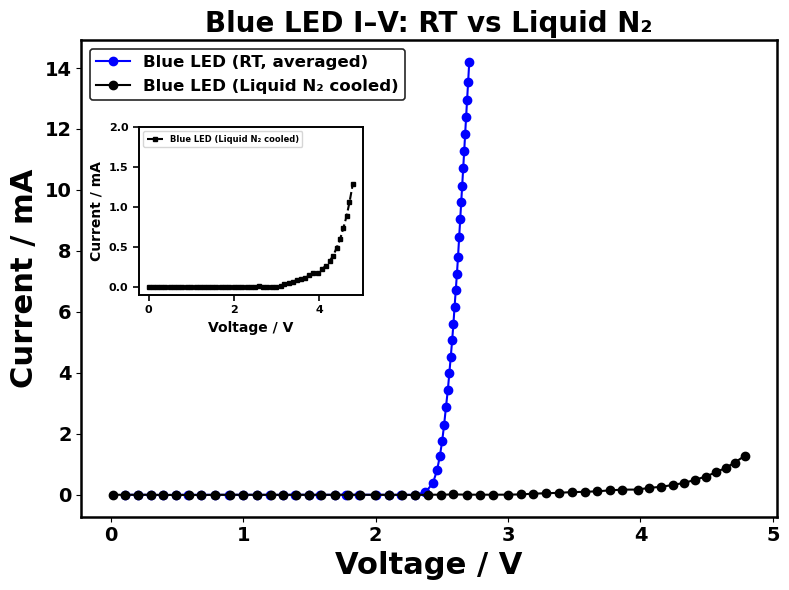

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/raw data/blue'

V_blue_rt, I_blue_rt = average_iv([
    f'{base_rt}/blue_IV.csv',
    f'{base_rt}/blue_IV_2.csv',
    f'{base_rt}/blue_IV_3.csv',
    f'{base_rt}/blue_IV_4.csv',
    f'{base_rt}/blue_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_blue_ln2, I_blue_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/blue_LiquidN2_cooled.csv'
)

# --------- Plot ----------
fig = plt.figure(figsize=(8, 6))     # <-- store figure in fig
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_blue_rt, I_blue_rt, 'o-', label='Blue LED (RT, averaged)', color='blue')
plt.plot(V_blue_ln2, I_blue_ln2, 'o-', label='Blue LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Blue LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---------- Inset plot ----------
inset_ax = fig.add_axes([0.18, 0.5, 0.28, 0.28])

inset_ax.plot(V_blue_ln2, I_blue_ln2, 's--', ms=3, color='black', label='Blue LED (Liquid N₂ cooled)')

inset_ax.set_xlabel("Voltage / V", fontsize=10, fontweight="bold")
inset_ax.set_ylabel("Current / mA", fontsize=10, fontweight="bold")

inset_ax.set_ylim(-0.1, 2)

inset_ax.tick_params(axis='both', width=1.2, length=4)
for tick in inset_ax.get_xticklabels() + inset_ax.get_yticklabels():
    tick.set_fontweight("bold")
    tick.set_fontsize(8)

for spine in inset_ax.spines.values():
    spine.set_linewidth(1.4)

inset_ax.legend(loc='upper left', prop={'size': 6, 'weight': 'bold'})

plt.savefig("Blue_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

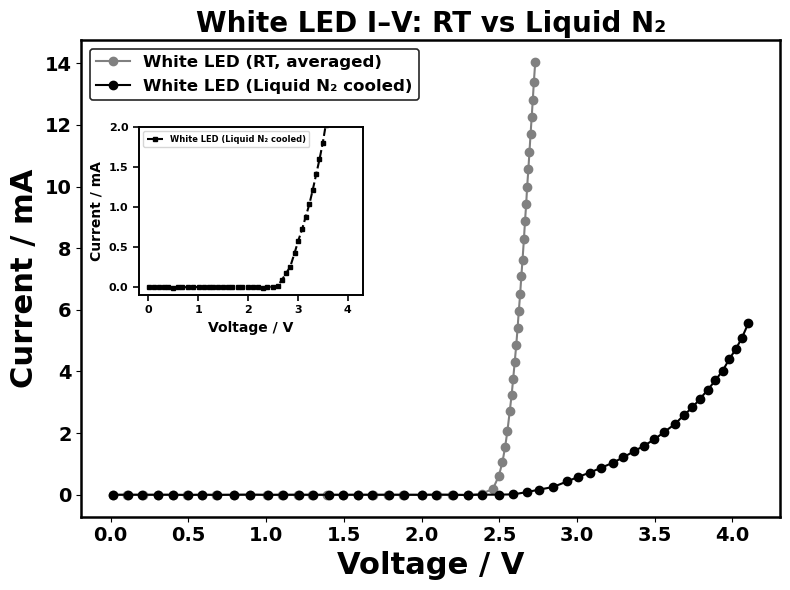

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/raw data/white'

V_white_rt, I_white_rt = average_iv([
    f'{base_rt}/white_IV.csv',
    f'{base_rt}/white_IV_2.csv',
    f'{base_rt}/white_IV_3.csv',
    f'{base_rt}/white_IV_4.csv',
    f'{base_rt}/white_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_white_ln2, I_white_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/white_LiquidN2_cooled.csv'
)

# --------- Plot ----------
fig = plt.figure(figsize=(8, 6))     # <-- store figure in fig
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_white_rt, I_white_rt, 'o-', label='White LED (RT, averaged)', color='grey')
plt.plot(V_white_ln2, I_white_ln2, 'o-', label='White LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('White LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---------- Inset plot ----------
inset_ax = fig.add_axes([0.18, 0.5, 0.28, 0.28])

inset_ax.plot(V_white_ln2, I_white_ln2, 's--', ms=3, color='black', label='White LED (Liquid N₂ cooled)')

inset_ax.set_xlabel("Voltage / V", fontsize=10, fontweight="bold")
inset_ax.set_ylabel("Current / mA", fontsize=10, fontweight="bold")

inset_ax.set_ylim(-0.1, 2)

inset_ax.tick_params(axis='both', width=1.2, length=4)
for tick in inset_ax.get_xticklabels() + inset_ax.get_yticklabels():
    tick.set_fontweight("bold")
    tick.set_fontsize(8)

for spine in inset_ax.spines.values():
    spine.set_linewidth(1.4)

inset_ax.legend(loc='upper left', prop={'size': 6, 'weight': 'bold'})

plt.savefig("White_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

# 3. Average Performance of I-V figures of 5 types of LEDs (with white) and the resistor

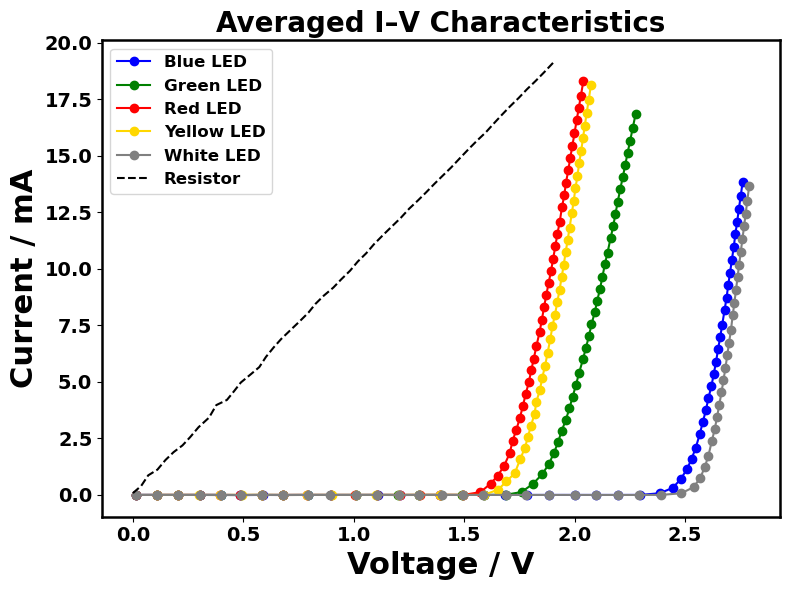

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs = []
    Is = []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V)
        Is.append(I)

    # target length = shortest run
    n = min(len(v) for v in Vs)

    Vs_trim = []
    Is_trim = []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V = V[drop:]
            I = I[drop:]
        else:
            V = V[:n]
            I = I[:n]
        Vs_trim.append(V)
        Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# ----------------- Existing base -----------------
base = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised'

# Load data
V_blue_avg, I_blue_avg = average_iv([
    f'{base}/blue/blue_IV_run1.csv',
    f'{base}/blue/blue_IV_run2.csv',
    f'{base}/blue/blue_IV_run3.csv',
    f'{base}/blue/blue_IV_run4.csv',
    f'{base}/blue/blue_IV_run5.csv',
])

V_green_avg, I_green_avg = average_iv([
    f'{base}/green/green_IV_run1.csv',
    f'{base}/green/green_IV_run2.csv',
    f'{base}/green/green_IV_run3.csv',
    f'{base}/green/green_IV_run4.csv',
    f'{base}/green/green_IV_run5.csv',
])

V_red_avg, I_red_avg = average_iv([
    f'{base}/red/red_IV_run1.csv',
    f'{base}/red/red_IV_run2.csv',
    f'{base}/red/red_IV_run3.csv',
    f'{base}/red/red_IV_run4.csv',
    f'{base}/red/red_IV_run5.csv',
])

V_yellow_avg, I_yellow_avg = average_iv([
    f'{base}/yellow/yellow_IV_run1.csv',
    f'{base}/yellow/yellow_IV_run2.csv',
    f'{base}/yellow/yellow_IV_run3.csv',
    f'{base}/yellow/yellow_IV_run4.csv',
    f'{base}/yellow/yellow_IV_run5.csv',
])

V_res_avg, I_res_avg = average_iv([
    f'{base}/resistor/resistor_IV_run1.csv',
    f'{base}/resistor/resistor_IV_run2.csv',
    f'{base}/resistor/resistor_IV_run3.csv',
    f'{base}/resistor/resistor_IV_run4.csv',
    f'{base}/resistor/resistor_IV_run5.csv',
])


V_white_avg, I_white_avg = average_iv([
    f'{base}/white/white_IV_run1.csv',
    f'{base}/white/white_IV_run2.csv',
    f'{base}/white/white_IV_run3.csv',
    f'{base}/white/white_IV_run4.csv',
    f'{base}/white/white_IV_run5.csv',
])

# ----------------- Plot -----------------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_blue_avg, I_blue_avg, 'o-', label='Blue LED', color='blue')
plt.plot(V_green_avg, I_green_avg, 'o-', label='Green LED', color='green')
plt.plot(V_red_avg, I_red_avg, 'o-', label='Red LED', color='red')
plt.plot(V_yellow_avg, I_yellow_avg, 'o-', label='Yellow LED', color='gold')
plt.plot(V_white_avg, I_white_avg, 'o-', label='White LED', color='grey')  # <-- added
plt.plot(V_res_avg, I_res_avg, 'k--', label='Resistor')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Averaged I–V Characteristics', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left')
plt.tight_layout()
plt.savefig("Averaged I–V Characteristics of LEDs and Resistor (with White).png", dpi=600)
plt.show()

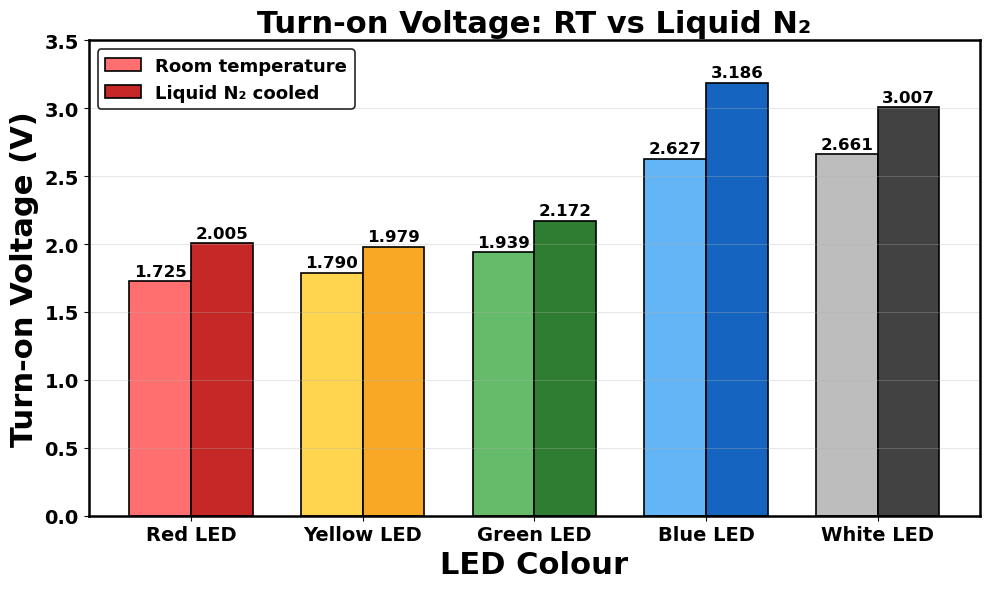

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) File paths
# =========================
rt_dir = r"/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/raw data_finalised"
ln2_dir = r"/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/extension work/LN2"

rt_csv = os.path.join(rt_dir, "Turn-on Voltages.csv")
ln2_csv = os.path.join(ln2_dir, "turn_on_voltages_LN2_cooled.csv")

# =========================
# 2) Load data
# =========================
df_rt = pd.read_csv(rt_csv)
df_ln2 = pd.read_csv(ln2_csv)

labels = ["Red LED", "Yellow LED", "Green LED", "Blue LED", "White LED"]
col_map = {
    "Red LED": "Red",
    "Yellow LED": "Yellow",
    "Green LED": "Green",
    "Blue LED": "Blue",
    "White LED": "White",
}

# RT means (multiple runs)
rt_means = [
    df_rt[col_map[lbl]].dropna().to_numpy(dtype=float).mean()
    for lbl in labels
]

# LN2 values (single measurement each)
ln2_values = [
    df_ln2[col_map[lbl]].dropna().to_numpy(dtype=float)[0]
    for lbl in labels
]

# =========================
# 3) Plot
# =========================
x = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Thicker frame
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

# Colour scheme: same family, LN2 darker
colors_rt = {
    "Red LED": "#ff6f6f",
    "Yellow LED": "#ffd54f",
    "Green LED": "#66bb6a",
    "Blue LED": "#64b5f6",
    "White LED": "#bdbdbd",
}

colors_ln2 = {
    "Red LED": "#c62828",
    "Yellow LED": "#f9a825",
    "Green LED": "#2e7d32",
    "Blue LED": "#1565c0",
    "White LED": "#424242",
}

# Bars
bars_rt = ax.bar(
    x - width/2, rt_means, width,
    color=[colors_rt[lbl] for lbl in labels],
    edgecolor='k', linewidth=1.2,
    label="Room temperature"
)

bars_ln2 = ax.bar(
    x + width/2, ln2_values, width,
    color=[colors_ln2[lbl] for lbl in labels],
    edgecolor='k', linewidth=1.2,
    label="Liquid N₂ cooled"
)

# =========================
# 4) Formatting
# =========================
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=14, fontweight='bold')
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f"{t:.1f}" for t in ax.get_yticks()],
                   fontsize=14, fontweight='bold')

ax.set_xlabel("LED Colour", fontsize=22, fontweight='bold')
ax.set_ylabel("Turn-on Voltage (V)", fontsize=22, fontweight='bold')
ax.set_title("Turn-on Voltage: RT vs Liquid N₂", fontsize=22, fontweight='bold')

ax.grid(axis='y', alpha=0.3)

# Annotate values
for bar in list(bars_rt) + list(bars_ln2):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.02,
        f"{h:.3f}",
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

# Legend (only RT vs LN2)
leg = ax.legend(
    prop={'size': 13, 'weight': 'bold'},
    loc='upper left',
    frameon=True,
    fancybox=True
)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()

out_path = os.path.join("/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260122/Figures/RT vs LN2", "Turn-on Voltage RT vs LN2.png")
plt.savefig(out_path, dpi=600)
plt.show()

# 4. Log-scale plot

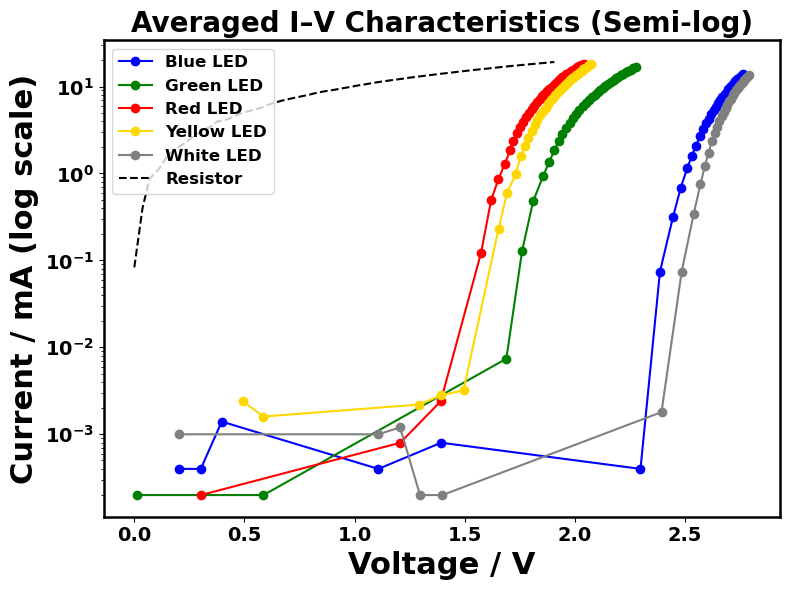

In [14]:
def plot_semilogy(V, I, **kwargs):
    mask = I > 0
    plt.plot(V[mask], I[mask], **kwargs)

# ----------------- Plot (log-scale y-axis) -----------------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plot_semilogy(V_blue_avg,   I_blue_avg,   marker='o', linestyle='-', label='Blue LED',   color='blue')
plot_semilogy(V_green_avg,  I_green_avg,  marker='o', linestyle='-', label='Green LED',  color='green')
plot_semilogy(V_red_avg,    I_red_avg,    marker='o', linestyle='-', label='Red LED',    color='red')
plot_semilogy(V_yellow_avg, I_yellow_avg, marker='o', linestyle='-', label='Yellow LED', color='gold')
plot_semilogy(V_white_avg,  I_white_avg,  marker='o', linestyle='-', label='White LED',  color='grey')
plot_semilogy(V_res_avg,    I_res_avg,    linestyle='--',            label='Resistor',   color='black')

ax.set_yscale('log')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA (log scale)', fontsize=22, fontweight="bold")
plt.title('Averaged I–V Characteristics (Semi-log)', fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left')
plt.tight_layout()
plt.savefig("Averaged I–V Characteristics (log-scale).png", dpi=600)
plt.show()